# Project 5B: Flow Matching from Scratch!

## Setup environment

In [ ]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.0 MB/s eta 0:00:00


In [ ]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm
import torch.optim
import torch

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [ ]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1)
        self.batchnorm = nn.BatchNorm2d(num_features=out_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv1(x)
        x = self.batchnorm(x)
        x = self.gelu(x)

        return x

        # ===== end of code ====
        raise NotImplementedError()


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=2, padding=1)
        self.batchnorm = nn.BatchNorm2d(num_features=out_channels)
        self.gelu = nn.GELU()

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv1(x)
        x = self.batchnorm(x)
        x = self.gelu(x)

        return x

        # ===== end of code ====
        raise NotImplementedError()


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====

        self.conv1 = nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=4, stride=2, padding=1)
        self.batchnorm = nn.BatchNorm2d(num_features=out_channels)
        self.gelu = nn.GELU()

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====

        x = self.conv1(x)
        x = self.batchnorm(x)
        x = self.gelu(x)

        return x

        # ===== end of code ====
        raise NotImplementedError()


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        # ===== your code here! ====

        self.pool = nn.AvgPool2d(7)

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.pool(x)

        return x

        # ===== end of code ====
        raise NotImplementedError()


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====

        self.conv1 = nn.ConvTranspose2d(in_channels=in_channels, out_channels=in_channels, kernel_size=7, stride=7, padding=0)
        self.batchnorm = nn.BatchNorm2d(num_features=in_channels)
        self.gelu = nn.GELU()

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv1(x)
        x = self.batchnorm(x)
        x = self.gelu(x)

        return x

        # ===== end of code ====
        raise NotImplementedError()


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====

        self.convBlock1 = Conv(in_channels, out_channels)
        self.convBlock2 = Conv(out_channels, out_channels)

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.convBlock1(x)
        x = self.convBlock2(x)

        return x

        # ===== end of code ====
        raise NotImplementedError()


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.downconv = DownConv(in_channels, out_channels)
        self.convblock = ConvBlock(out_channels, out_channels)

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.downconv(x)
        x = self.convblock(x)

        return x

        # ===== end of code ====
        raise NotImplementedError()


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====

        self.upconv = UpConv(in_channels, out_channels)
        self.convblock = ConvBlock(out_channels, out_channels)

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.upconv(x)
        x = self.convblock(x)

        return x

        # ===== end of code ====
        raise NotImplementedError()

## Implementing Unconditional UNet

In [ ]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int, # number of hidden channels, hyperparam we set. basically number of kernels we will apply on our image
    ):
        super().__init__()
        # ===== your code here! ====
        self.convblock1 = ConvBlock(in_channels, num_hiddens)
        self.downblock1 = DownBlock(num_hiddens, num_hiddens)
        self.downblock2 = DownBlock(num_hiddens, num_hiddens * 2)
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)

        self.upblock1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.upblock2 = UpBlock(num_hiddens * 2, num_hiddens)

        self.convblock2 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.conv = nn.Conv2d(in_channels=num_hiddens, out_channels=1, kernel_size=3, stride=1, padding=1)

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        block1_out = self.convblock1(x)
        downblock1_out = self.downblock1(block1_out)
        downblock2_out = self.downblock2(downblock1_out)

        flattened = self.flatten(downblock2_out)
        unflattened = self.unflatten(flattened)

        pre_upblock1 = torch.concat([downblock2_out, unflattened], dim=1)

        # print("shapes: ", downblock2_out.shape, unflattened.shape)

        upblock1_out = self.upblock1(pre_upblock1)

        pre_upblock2 = torch.concat([upblock1_out, downblock1_out], dim=1)

        upblock2_out = self.upblock2(pre_upblock2)

        pre_convblock = torch.concat([upblock2_out, block1_out], dim=1)

        convblock2_out = self.convblock2(pre_convblock)

        x = self.conv(convblock2_out)

        return x



        # ===== end of code ====
        raise NotImplementedError()

# Part 1.2: Using the UNet to Train a Denoiser

In [ ]:
# Visualize images at different noisy level
# ===== your code here! ====

sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]




def add_noise(x, sigma):
  # sigma = np.random.choice(sigmas)
  epsilon = torch.randn_like(x).to(device)

  z = x + sigma * epsilon

  return z

def pure_noise(x):
  return torch.randn_like(x).to(device)

def visualize_noise(x, sigmas):
  fig, axes = plt.subplots(nrows=1, ncols=len(sigmas), figsize=(16, 10))

  for i in range(len(axes)):
    noisy_image = add_noise(x.to(device), sigmas[i])


    axes[i].imshow(noisy_image.cpu().permute(1, 2, 0), cmap='gray')
    axes[i].axis("off")
    axes[i].set_title(f"Sigma={sigmas[i]}")





# ===== end of code ====

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [ ]:
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 256
learning_rate = 1e-4
noise_level = 0.5
hidden_dim = 128
num_epochs = 5
# ===== end of code ====

In [ ]:
# Define your datasets and dataloaders
# ===== your code here! ====

train_dataset = MNIST(root="./data", train=True, transform=ToTensor(), download=True)
test_dataset = MNIST(root="./data", train=False, transform=ToTensor(), download=True)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
# ===== end of code ====

torch.Size([28, 28])


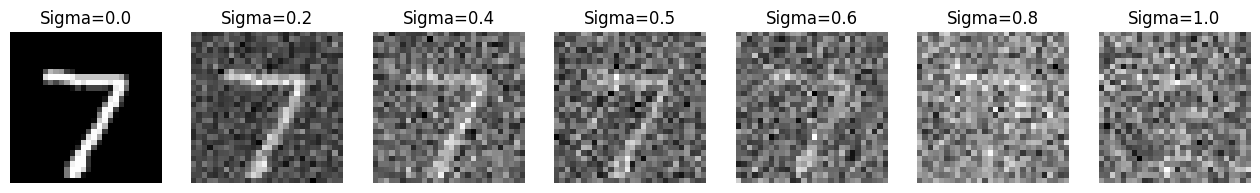

In [ ]:
# visualizing noise

batches, _ = next(iter(test_loader))
batch_1 = batches[0]
image = batch_1[0]
print(image.shape)
image = image.unsqueeze(0)





visualize_noise(image, sigmas)

In [ ]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

criterion = nn.MSELoss()
# ===== end of code ====

100%|██████████| 235/235 [01:28<00:00,  2.65it/s]


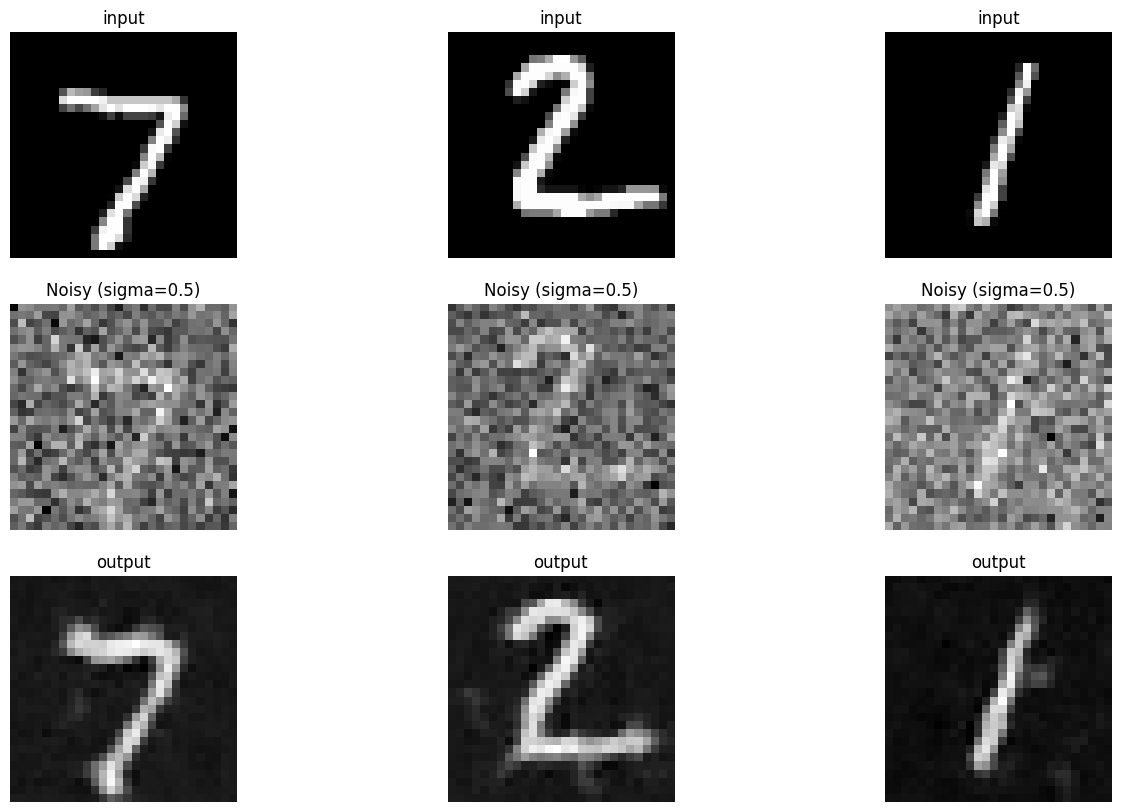

100%|██████████| 235/235 [01:32<00:00,  2.55it/s]


In [ ]:
# The training loops
train_losses = []
for epoch in range(num_epochs):
    if epoch == 1:
      fig, axes = plt.subplots(3, 3, figsize=(16, 10))
      axes = axes.flatten()
      batch_images, batch_labels = next(iter(test_loader))

      original_images = batch_images[0:3]
      noisy_images = add_noise(batch_images.to(device), noise_level)
      cleaned_images = model(noisy_images)

      for i in range(0, 3):
        axes[i].imshow(original_images[i].permute(1, 2, 0), cmap='gray')
        axes[i].axis("off")
        axes[i].set_title("input")

        axes[i + 3].imshow(noisy_images[i].cpu().permute(1, 2, 0), cmap='gray')
        axes[i + 3].axis("off")
        axes[i + 3].set_title("Noisy (sigma=0.5)")

        axes[i + 6].imshow(cleaned_images[i].detach().cpu().permute(1, 2, 0), cmap='gray')
        axes[i + 6].axis("off")
        axes[i + 6].set_title("output")

      plt.show()

    for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)
        # ===== your code here! ====
        # print(len(images))
        # print(images.shape)

        noisy_images = add_noise(images, noise_level)

        outputs = model(noisy_images)

        # ===== end of code ====

        # print(outputs.device, images.device)

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

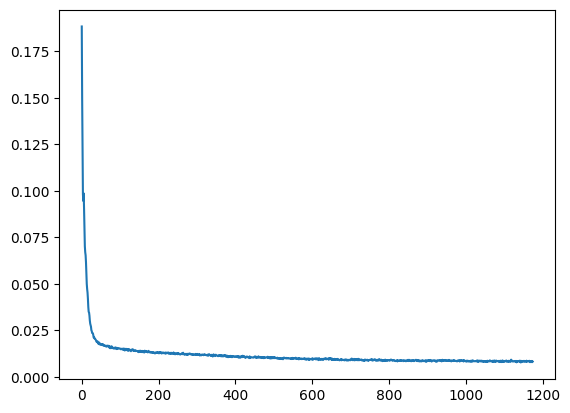

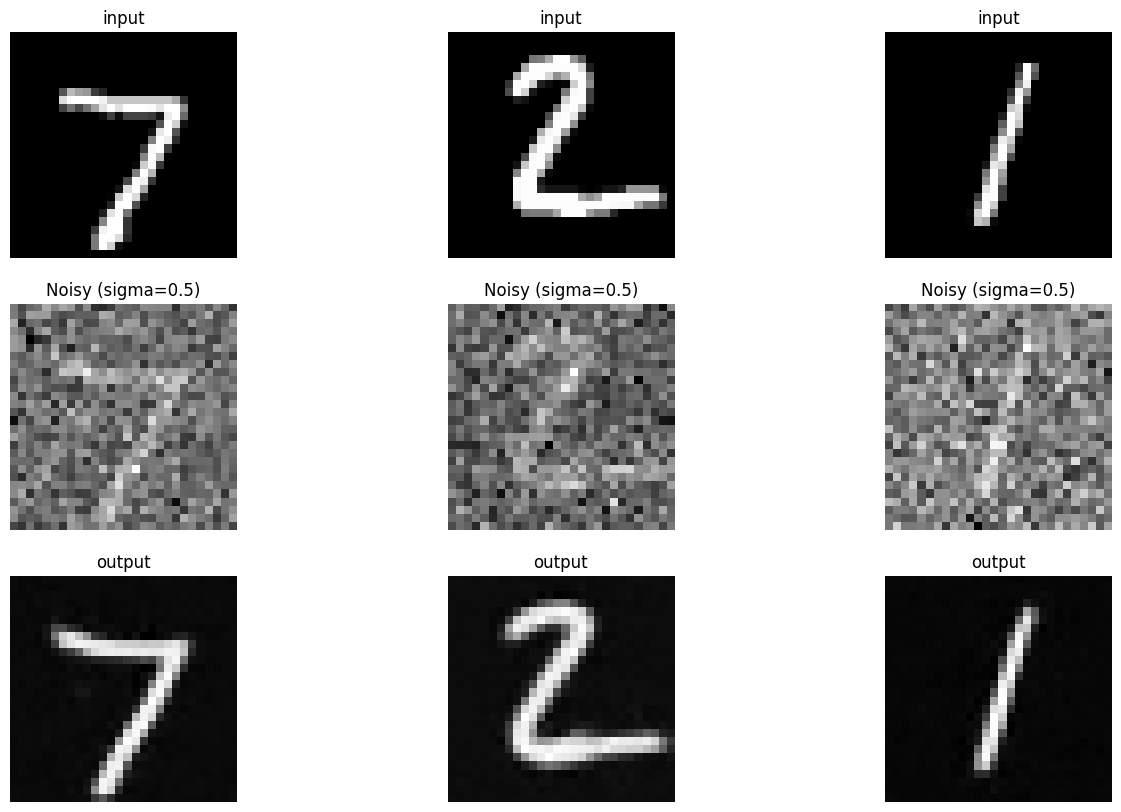

In [ ]:
# Visualize your training curve
# ===== your code here! ====
import numpy as np
plt.plot(range(0, 1175), train_losses)
plt.show()

# state_dict = torch.load("./weights/model_weights.pth")
# model.load_state_dict(state_dict)

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()
batch_images, batch_labels = next(iter(test_loader))

original_images = batch_images[0:3]
noisy_images = add_noise(batch_images.to(device), noise_level)
cleaned_images = model(noisy_images)

for i in range(0, 3):
  axes[i].imshow(original_images[i].permute(1, 2, 0), cmap='gray')
  axes[i + 3].imshow(noisy_images[i].cpu().permute(1, 2, 0), cmap='gray')
  axes[i + 6].imshow(cleaned_images[i].detach().cpu().permute(1, 2, 0), cmap='gray')
  axes[i].axis("off")
  axes[i + 3].axis("off")
  axes[i + 6].axis("off")
  axes[i].set_title("input")
  axes[i + 3].set_title("Noisy (sigma=0.5)")
  axes[i + 6].set_title("output")
plt.show()



# ===== end of code ====

## Part 1.2.2: Out-of-Distribution Testing

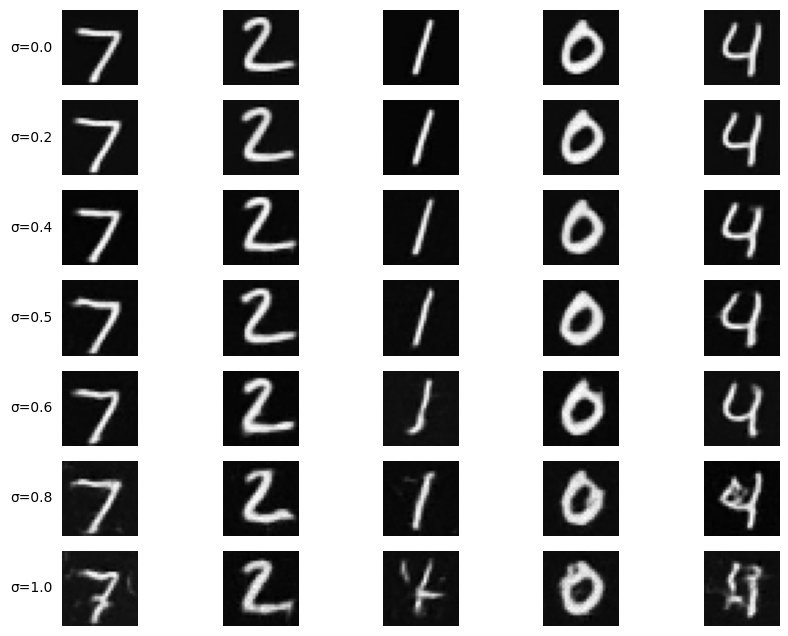

In [ ]:
# Visualize OOD testing
# ===== your code here! ====

batch_images, batch_labels = next(iter(test_loader))

original_images = batch_images[0:5]

fig, axes = plt.subplots(len(sigmas), 5, figsize=(10, 8))

for i in range(len(sigmas)):
    noisy_images = add_noise(original_images.to(device), sigmas[i])
    cleaned_images = model(noisy_images)

    for j in range(5):
        ax = axes[i, j]
        ax.imshow(cleaned_images[j].detach().cpu().permute(1, 2, 0), cmap='gray')
        ax.axis("off")

        if j == 0:
            ax.text(-20, 15, f"σ={sigmas[i]}", fontsize=10)


plt.show()

# ===== end of code ====

## Part 1.2.3 Denoising Pure Noise

100%|██████████| 235/235 [01:31<00:00,  2.56it/s]


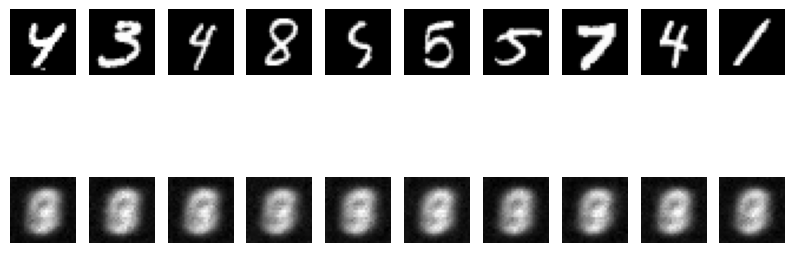

100%|██████████| 235/235 [01:31<00:00,  2.56it/s]


In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====


pure_noise_model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
pure_noise_optimizer = torch.optim.Adam(pure_noise_model.parameters(), lr=1e-4)

train_losses = []
for epoch in range(num_epochs):
    if epoch == 1:
      batch_images, batch_labels = next(iter(train_loader))
      original_images = batch_images[0:10]

      fig, axes = plt.subplots(2, 10, figsize=(10, 4))
      axes = axes.flatten()

      for i in range(0, 10):
        axes[i].imshow(original_images[i].cpu().permute(1, 2, 0), cmap='gray')
        axes[i].axis("off")

      noisy_images = pure_noise(original_images)

      generated_images = pure_noise_model(noisy_images)

      for i in range(10, len(axes)):
        axes[i].imshow(generated_images[i - 10].detach().cpu().permute(1, 2, 0), cmap='gray')
        axes[i].axis("off")
      plt.show()

    for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)
        # ===== your code here! ====
        # print(len(images))
        # print(images.shape)

        noisy_images = pure_noise(images)

        outputs = pure_noise_model(noisy_images)

        # ===== end of code ====

        # print(outputs.device, images.device)

        loss = criterion(outputs, images)
        pure_noise_optimizer.zero_grad()
        loss.backward()
        pure_noise_optimizer.step()

        train_losses.append(loss.item())





# ===== end of code ====

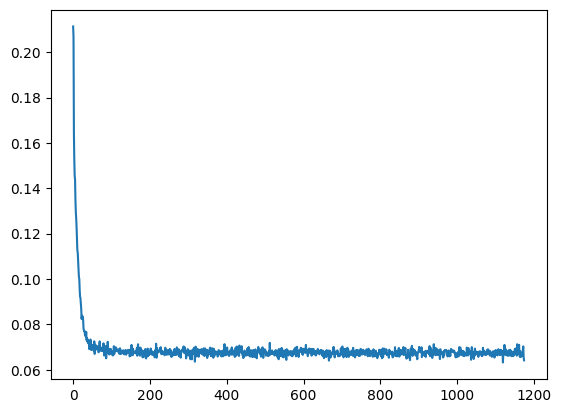

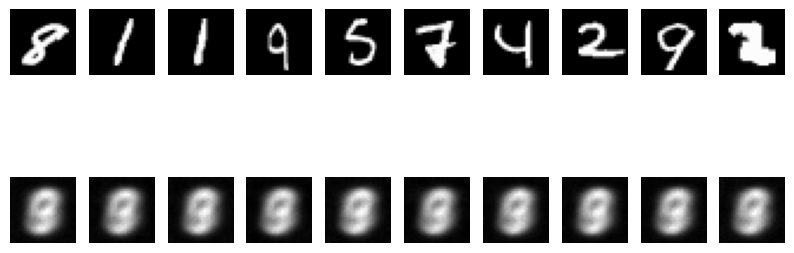

In [ ]:
plt.plot(range(0, 1175), train_losses)
plt.show()

batch_images, batch_labels = next(iter(train_loader))

original_images = batch_images[0:10]

fig, axes = plt.subplots(2, 10, figsize=(10, 4))
axes = axes.flatten()

for i in range(0, 10):
  axes[i].imshow(original_images[i].cpu().permute(1, 2, 0), cmap='gray')
  axes[i].axis("off")

noisy_images = pure_noise(original_images)

generated_images = pure_noise_model(noisy_images)

for i in range(10, len(axes)):
  axes[i].imshow(generated_images[i - 10].detach().cpu().permute(1, 2, 0), cmap='gray')
  axes[i].axis("off")
plt.show()



# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [ ]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====

        self.L1 = nn.Linear(in_channels, out_channels)
        self.L2 = nn.Linear(out_channels, out_channels)
        self.gelu = nn.GELU()

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # print("x.shape before", x.shape)
        # ===== your code here! ====
        x = self.L1(x)
        x = self.L2(x)
        x = self.gelu(x)

        # print("shape here", x.shape)

        x = x.permute(0, 3, 1, 2)

        return x

        # ===== end of code ====
        raise NotImplementedError()


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        self.convblock1 = ConvBlock(in_channels, num_hiddens)
        self.downblock1 = DownBlock(num_hiddens, num_hiddens)
        self.downblock2 = DownBlock(num_hiddens, num_hiddens * 2)
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)


        self.fc1 = FCBlock(1, 2 * num_hiddens)# t is a scalar, so 1 in feature
        self.fc2 = FCBlock(1, num_hiddens)

        self.upblock1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.upblock2 = UpBlock(num_hiddens * 2, num_hiddens)

        self.convblock2 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.conv = nn.Conv2d(in_channels=num_hiddens, out_channels=1, kernel_size=3, stride=1, padding=1)


        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        # print("hey we got t here", t)
        block1_out = self.convblock1(x)
        downblock1_out = self.downblock1(block1_out)
        downblock2_out = self.downblock2(downblock1_out)

        flattened = self.flatten(downblock2_out)
        unflattened = self.unflatten(flattened)

        # print("shape", t.shape)

        fc1_out = self.fc1(t)
        # print("shapes ", fc1_out.shape, unflattened.shape)

        conditioned_one = unflattened * fc1_out

        pre_upblock1 = torch.concat([downblock2_out, conditioned_one], dim=1)

        # print("shapes: ", downblock2_out.shape, unflattened.shape)

        upblock1_out = self.upblock1(pre_upblock1)

        fc2_out = self.fc2(t)
        conditioned_two = upblock1_out * fc2_out

        pre_upblock2 = torch.concat([downblock1_out, conditioned_two], dim=1)

        upblock2_out = self.upblock2(pre_upblock2)

        pre_convblock = torch.concat([upblock2_out, block1_out], dim=1)

        convblock2_out = self.convblock2(pre_convblock)

        x = self.conv(convblock2_out)

        return x

        # ===== end of code ====
        raise NotImplementedError()

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [ ]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N, c, h, w = x_1.shape
    t = torch.rand(N, device=device)
    # print("t value", t)

    t = t.reshape(N, 1, 1, 1)

    x_0 = torch.randn_like(x_1, device=device) # pure noise image

    # print("shapes", x_0.shape, x_1.shape, t.shape)

    x_t = (1 - t) * x_0 + t * x_1 # linear interpolation with noisy image and clean image

    pred = unet(x_t, t)

    # print('prediction')
    # plt.imshow(pred[0].detach().cpu().permute(1, 2, 0), cmap='gray')
    # plt.show()

    loss = nn.MSELoss()

    return loss(pred, x_1 - x_0)

    # ===== end of code ====
    raise NotImplementedError()

In [ ]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====

    N = 40 # how many images i want to sample,
    C = 1
    H, W = img_wh

    x_t = torch.randn((N, C, H, W), device=device)
    for i in range(num_ts):
      t_val = i / num_ts
      t = torch.tensor([t_val], dtype=torch.float32, device=device)
      t = t.repeat(N)
      t = t.reshape(N, 1, 1, 1)

      # print("t value", t)
      # print("shape t", t.shape, t.dtype)


      # print("t ", t)
      x_t = x_t + (1 / num_ts) * unet(x_t, t)

    return x_t

    # ===== end of code ====
    raise NotImplementedError()

In [ ]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

100%|██████████| 938/938 [00:40<00:00, 22.94it/s]


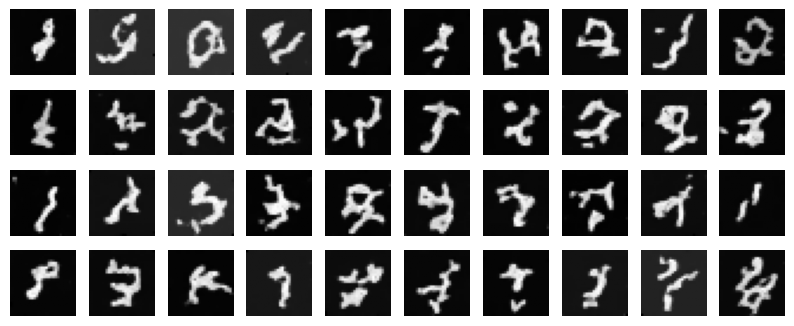

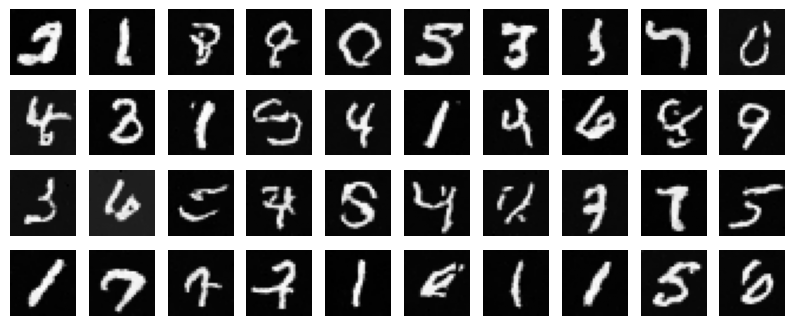

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 64
learning_rate = 1e-2
hidden_dim = 64
num_epochs = 10

train_dataset = MNIST(root="./data", train=True, transform=ToTensor(), download=True)
test_dataset = MNIST(root="./data", train=False, transform=ToTensor(), download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


time_cond_model = TimeConditionalUNet(in_channels=1, num_hiddens=hidden_dim, num_classes=0).to(device)

optimizer = torch.optim.Adam(time_cond_model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1 ** (1 / num_epochs)) ## add params

criterion = nn.MSELoss()

FM = TimeConditionalFM(time_cond_model) # num_ts and height width already defined
train_losses = []

for epoch in range(0, num_epochs):
  #epoch 1 visualizaton
  if epoch == 1:
    test_data = next(iter(test_dataset))
    fig, axes = plt.subplots(nrows=4, ncols=10, figsize=(10, 4))
    axes = axes.flatten()

    samples = FM.sample(FM.img_hw)

    for i in range(40):
      axes[i].imshow(samples[i].cpu().permute(1, 2, 0), cmap='gray')
      axes[i].axis("off")

  # epoch 5 visualization
  elif epoch == 5:
    test_data = next(iter(test_dataset))
    fig2, axes2 = plt.subplots(nrows=4, ncols=10, figsize=(10, 4))
    axes2 = axes2.flatten()

    samples = FM.sample(FM.img_hw)

    for i in range(40):
      axes2[i].imshow(samples[i].cpu().permute(1, 2, 0), cmap='gray')
      axes2[i].axis("off")

  for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)

        loss = FM(images)

        # ===== end of code ====

        # print(outputs.device, images.device)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
  scheduler.step()



# ===== end of code ====

# Part 2.3: Sampling from the Time-conditioned UNet

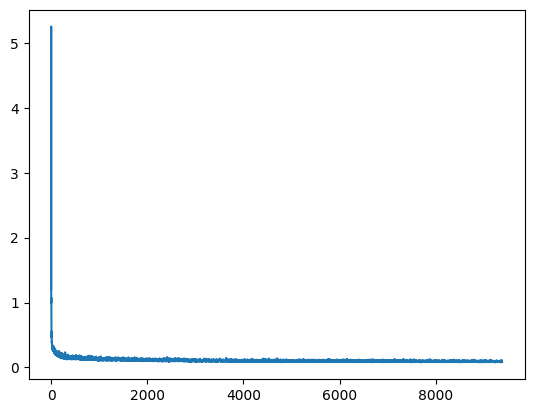

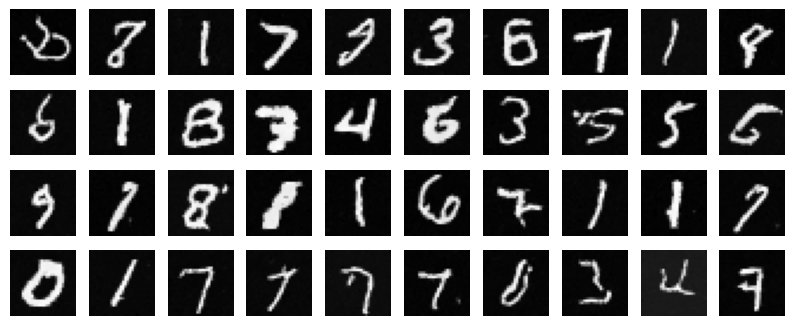

In [ ]:
# Sampling from the UNet
# ===== your code here! ====
plt.plot(range(0, 9380), train_losses)
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=10, figsize=(10, 4))
axes = axes.flatten()

#epoch 10 visualization
for i in range(len(axes)):

  samples = FM.sample(FM.img_hw)

  axes[i].imshow(samples[i].cpu().permute(1, 2, 0), cmap='gray')
  axes[i].axis("off")

plt.show()


# ===== end of code ====

# Part 2.4: Implementing a Class-conditioned UNet

In [ ]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====

        self.convblock1 = ConvBlock(in_channels, num_hiddens)
        self.downblock1 = DownBlock(num_hiddens, num_hiddens)
        self.downblock2 = DownBlock(num_hiddens, num_hiddens * 2)
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)


        self.fc1_t = FCBlock(1, 2 * num_hiddens)# t is a scalar, so 1 in feature
        self.fc2_t = FCBlock(1, num_hiddens)

        self.fc1_c = FCBlock(num_classes, 2 * num_hiddens)
        self.fc2_c = FCBlock(num_classes, num_hiddens)

        self.upblock1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.upblock2 = UpBlock(num_hiddens * 2, num_hiddens)

        self.convblock2 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.conv = nn.Conv2d(in_channels=num_hiddens, out_channels=1, kernel_size=3, stride=1, padding=1)

        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====

        block1_out = self.convblock1(x)
        downblock1_out = self.downblock1(block1_out)
        downblock2_out = self.downblock2(downblock1_out)

        flattened = self.flatten(downblock2_out)
        unflattened = self.unflatten(flattened)

        # masking our C in the case were conditioning/nonconditioning

        t1 = self.fc1_t(t)
        c1 = self.fc1_c(c)
        # print("shapes ", c1.shape)

        conditioned_one = unflattened * c1 + t1

        pre_upblock1 = torch.concat([downblock2_out, conditioned_one], dim=1)

        # print("shapes: ", downblock2_out.shape, unflattened.shape)

        upblock1_out = self.upblock1(pre_upblock1)

        t2 = self.fc2_t(t)
        c2 = self.fc2_c(c)

        conditioned_two = upblock1_out * c2 + t2

        pre_upblock2 = torch.concat([downblock1_out, conditioned_two], dim=1)

        upblock2_out = self.upblock2(pre_upblock2)

        pre_convblock = torch.concat([upblock2_out, block1_out], dim=1)

        convblock2_out = self.convblock2(pre_convblock)

        x = self.conv(convblock2_out)

        return x



        # ===== end of code ====
        raise NotImplementedError()

In [ ]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N, C, H, W = x_1.shape

    c_one_hot = torch.nn.functional.one_hot(c, num_classes=10).float().to(device)
    c_one_hot = c_one_hot.reshape(N, 1, 1, 10)

    probs = torch.rand(N, device=device)
    drop_mask = probs < p_uncond

    c_one_hot[drop_mask] = 0 # masking based on probability


    t = torch.rand(N, device=device)
    t = t.reshape(N, 1, 1, 1)

    x_0 = torch.randn_like(x_1, device=device) # pure noise image
    # print(rand_float, p_uncond)

    x_t = (1 - t) * x_0 + t * x_1

    pred = unet(x_t, c_one_hot, t)

    # if rand_float <= p_uncond:
    #   # we uncondition it, no class condition
    #   # error is just (x1 - x0) -
    #   c_one_hot_zero = torch.zeros_like(c_one_hot, dtype=torch.float32, device=device)
    #   pred = unet(x_0, c_one_hot_zero, t)
    # else:
    #   pred = unet(x_0, c_one_hot, t)

    loss = criterion(pred, x_1 - x_0)

    return loss




    # ===== end of code ====
    raise NotImplementedError()

In [ ]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # ===== your code here! ====
    N = c.shape[0]
    C = 1
    H, W = img_wh

    c_one_hot = torch.nn.functional.one_hot(c, num_classes=10).float().to(device)
    # print("c_one_hot", c_one_hot, "shape ", c_one_hot.shape)
    # print("N", N)

    c_one_hot = c_one_hot.reshape(N, 1, 1, 10)

    x_t = torch.randn((N, C, H, W), device=device)

    for i in range(num_ts):
      t = torch.tensor(i / num_ts, device=device)
      t = t.repeat(N)

      t = t.reshape(N, 1, 1, 1)

      c_0 = torch.zeros_like(c_one_hot, dtype=torch.float32, device=device)
      uncond = unet(x_t, c_0, t)

      cond = unet(x_t, c_one_hot, t)

      result = uncond + guidance_scale * (cond - uncond)

      x_t = x_t + (1 / num_ts) * result

    return x_t


    # ===== end of code ====
    raise NotImplementedError()

In [ ]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

100%|██████████| 938/938 [00:41<00:00, 22.87it/s]


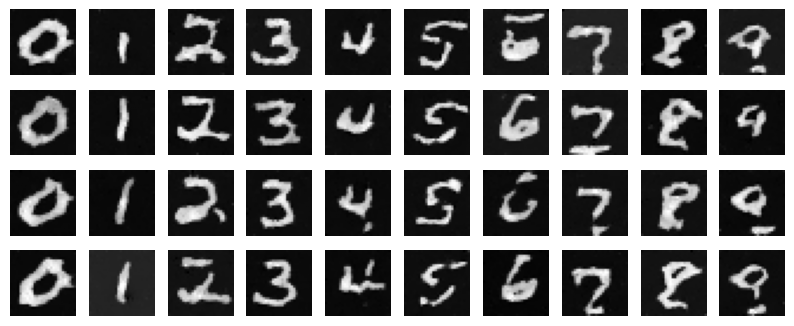

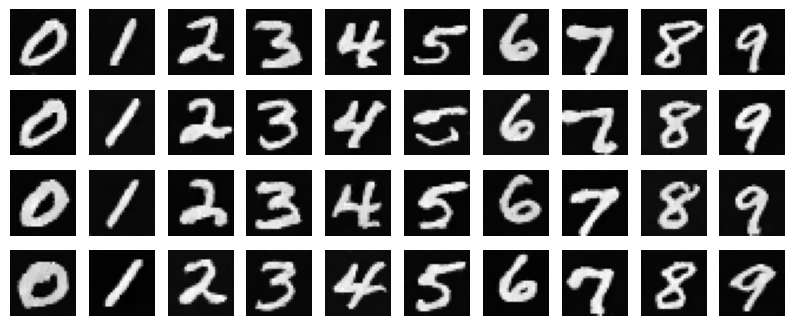

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====

# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 64
learning_rate = 1e-2
hidden_dim = 64
num_epochs = 10

train_dataset = MNIST(root="./data", train=True, transform=ToTensor(), download=True)
test_dataset = MNIST(root="./data", train=False, transform=ToTensor(), download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


class_cond_model = ClassConditionalUNet(in_channels=1, num_hiddens=hidden_dim, num_classes=10).to(device)

optimizer = torch.optim.Adam(class_cond_model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1 ** (1 / num_epochs)) ## add params

criterion = nn.MSELoss()

class_FM = ClassConditionalFM(class_cond_model) # num_ts and height width already defined
train_losses = []
for epoch in range(0, num_epochs):
  if epoch == 1:
    fig, axes = plt.subplots(nrows=4, ncols=10, figsize=(10, 4))
    axes = axes.flatten()

    c_batch = torch.arange(40).fmod(10).to(device)
    samples = class_FM.sample(c_batch, (28, 28))

    for idx in range(0, 40):
      axes[idx].imshow(samples[idx].cpu().permute(1, 2, 0), cmap='gray')
      axes[idx].axis("off")

  elif epoch == 5:
    fig2, axes2 = plt.subplots(nrows=4, ncols=10, figsize=(10, 4))
    axes2 = axes2.flatten()

    c_batch = torch.arange(40).fmod(10).to(device)
    samples = class_FM.sample(c_batch, (28, 28))

    for idx in range(0, 40):
      axes2[idx].imshow(samples[idx].cpu().permute(1, 2, 0), cmap='gray')
      axes2[idx].axis("off")

  for i, (images, labels) in enumerate(tqdm(train_loader)):
        images = images.to(device)
        c = labels.to(device)

        loss = class_FM(images, c)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())






plt.show()

# ===== end of code ====

# Part 2.6: Sampling from the Class-conditioned UNet

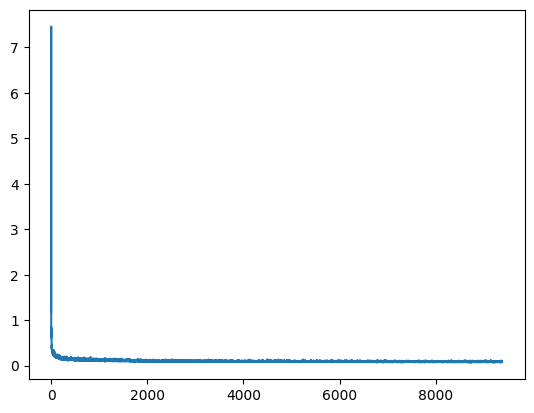

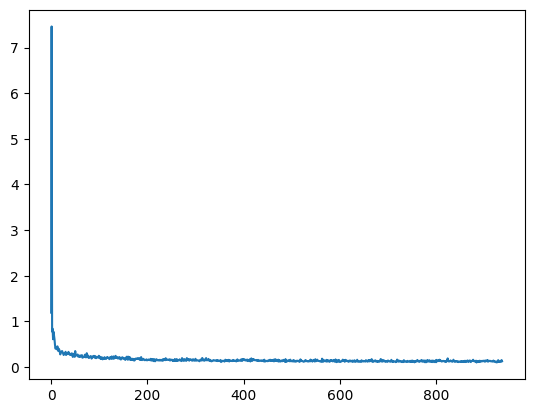

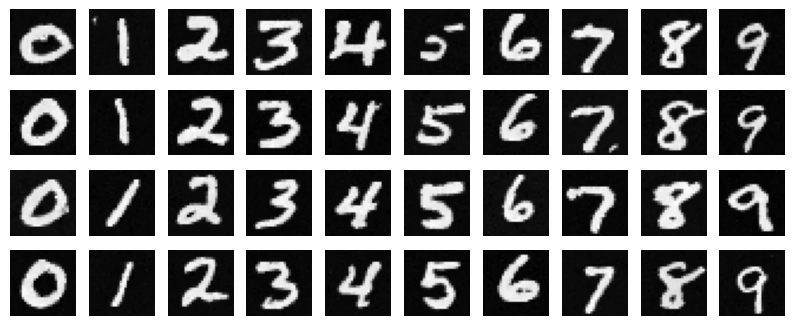

In [ ]:
# Sampling from the UNet
# ===== your code here! ====
plt.plot(range(0, 9380), train_losses)
plt.show()

plt.plot(range(0, 938), train_losses[0:938])
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=10, figsize=(10, 4))
axes = axes.flatten()

c_batch = torch.arange(40).fmod(10).to(device)
samples = class_FM.sample(c_batch, (28, 28))
# print(samples[idx].shape)
# print(samples.shape)

for idx in range(len(axes)):
  axes[idx].imshow(samples[idx].cpu().permute(1, 2, 0), cmap='gray')
  axes[idx].axis("off")


# for i in range(len(axes)):

#   c = torch.tensor(i % 10).to(device)

#   sample = class_FM.sample(c, (28, 28))

#   axes[i].imshow(sample.cpu().squeeze(0).permute(1, 2, 0), cmap='gray')
#   axes[i].axis("off")

plt.show()



# ===== end of code ====